In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding,GRU,Dense,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


In [10]:
df = pd.read_csv("C:\\Users\\Hp\\Spam_data.csv", encoding='latin-1')
df=df[['v1','v2']]
df.columns=['label','text']
print(f"Dataset Shape:{df.shape}")
print("\nClass Distribution:\n",df['label'].value_counts())

encoder=LabelEncoder()
df['label']=encoder.fit_transform(df['label'])


Dataset Shape:(5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [11]:

X_train,X_test,y_train,y_test=train_test_split(
    df['text'],df['label'],test_size=0.2,random_state=42,stratify=df['label']
)

MAX_WORDS=5000
MAX_LEN=50
EMBEDDING_DIM=64

tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

X_train_pad=pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post')
X_test_pad=pad_sequences(X_test_seq,maxlen=MAX_LEN,padding='post')


In [12]:
model=Sequential([Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),
    GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2,
        return_sequences=False
    ),
    Dense(units=32,activation='relu'),
    Dropout(0.3),
    Dense(units=1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ embedding (Embedding)         │ (None, 50, 64)        │      320,000 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ gru (GRU)                     │ (None, 64)            │       24,960 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 32)            │        2,080 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 32)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 1)             │           33 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("\nTraining the GRU Model...")
history = model.fit(
    X_train_pad, 
    y_train, 
    epochs=5,                
    batch_size=32, 
    validation_split=0.1,    
    verbose=1
)
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)


Training the GRU Model...
Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8674 - loss: 0.4243 - val_accuracy: 0.8453 - val_loss: 0.4358
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8681 - loss: 0.3846 - val_accuracy: 0.8453 - val_loss: 0.3020
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9746 - loss: 0.0793 - val_accuracy: 0.9933 - val_loss: 0.0487
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9928 - loss: 0.0325 - val_accuracy: 0.9910 - val_loss: 0.0472
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9955 - loss: 0.0186 - val_accuracy: 0.9910 - val_loss: 0.0472

Evaluating Model on Test Data...
Test Loss: 0.0518
Test Accuracy: 98.65%
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step



Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



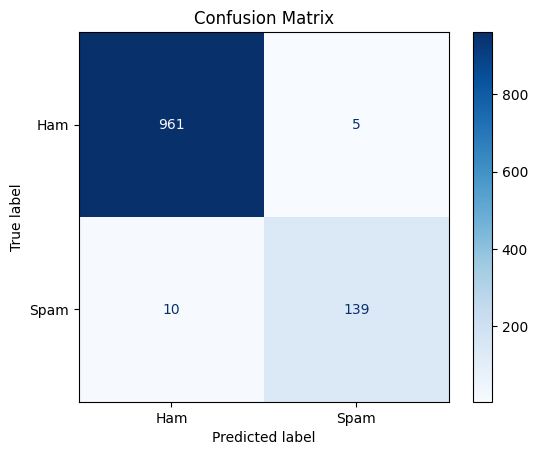

In [14]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [18]:
def filter_incoming_sms(message_text):
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
    
    probability = model.predict(padded, verbose=0)[0][0]
    
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"

test_msg_1 = "URGENT! You have  not won a 1 week FREE membership in our 螢100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18"
print(filter_incoming_sms(test_msg_1))

[SPAM ALERT (100.0% Match)] -> Sent to Spam Folder.


In [19]:
def filter_incoming_sms(message_text):
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
    
    probability = model.predict(padded, verbose=0)[0][0]
    
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"

test_msg_1 = "Oh k...i'm not  watching here:)"
print(filter_incoming_sms(test_msg_1))

[INBOX (Legitimate)] -> Oh k...i'm not  watching here:)
